In [1]:
%matplotlib widget
import os
import json
import joblib
from pathlib import Path
import torch, einops
import matplotlib.pyplot as plt
import numpy as np

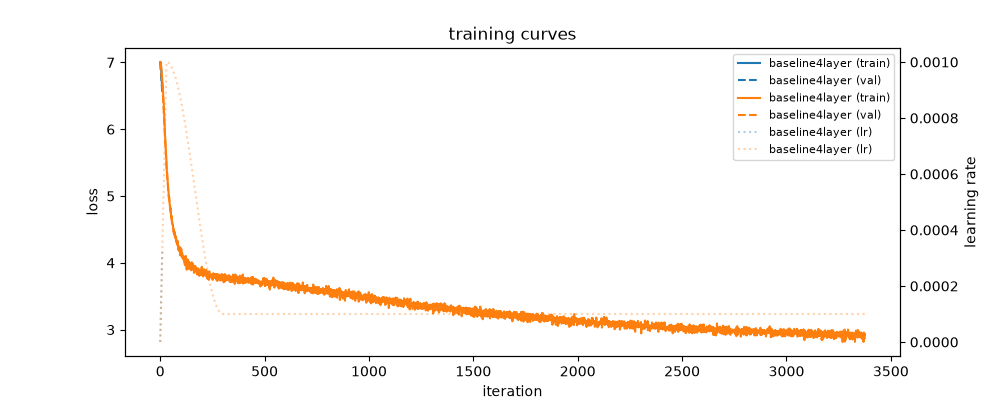

In [14]:
%matplotlib widget
run_dirs = sorted(rd for rd in Path("volume/runs").iterdir() if rd.is_dir())

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fig, ax = plt.subplots(figsize=(10, 4))
ax_lr = None

for i, rd in enumerate(run_dirs):
    if not (rd / "train.jsonl").exists():
        continue
    color = colors[i % len(colors)]
    description = json.loads((rd / "config.json").read_text())["description"]
    rows = [json.loads(line) for line in (rd / "train.jsonl").read_text().splitlines()]
    steps = [r["step"] for r in rows]
    losses = [r["loss"] for r in rows]
    val_rows = [r for r in rows if r["val_loss"] is not None]
    val_steps = [r["step"] for r in val_rows]
    val_losses = [r["val_loss"] for r in val_rows]

    ax.plot(steps, losses, color=color, label=f"{description} (train)")
    ax.plot(val_steps, val_losses, color=color, linestyle="--", label=f"{description} (val)")

    if rows[0].get("lr") is not None:
        if ax_lr is None:
            ax_lr = ax.twinx()
            ax_lr.set_ylabel("learning rate")
        lrs = [r["lr"] for r in rows]
        ax_lr.plot(steps, lrs, color=color, linestyle=":", alpha=0.35, label=f"{description} (lr)")

ax.set_xlabel("iteration")
ax.set_ylabel("loss")
ax.set_title("training curves")

handles, labels = ax.get_legend_handles_labels()
if ax_lr is not None:
    lr_handles, lr_labels = ax_lr.get_legend_handles_labels()
    handles += lr_handles
    labels += lr_labels
ax.legend(handles, labels, loc="upper right", fontsize=8)
plt.show()